<a href="https://colab.research.google.com/github/ismethakanaydogmus/konya-agriculture-price-predictor/blob/main/Konya_Agriculture_ML_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Local Agricultural Price & Climate Predictor — Model Training & Evaluation
### Forecasting Agricultural Price Fluctuation (Fiyat_Degisim_Yuzdesi)
---
> **This is Part 2 of 2.** Part 1 (EDA) explored the agricultural market and climate data, engineered features, and established the chronological split. This notebook picks up from that result (using the `konya_tarim_final_modeling_ready.csv` dataset) and trains the regression algorithms taught in the lecture plus additional ML models.
>
> Click **"Show / Hide Code"** at the top-right to reveal implementation details.

---

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Presentation CSS + Toggle Button  (purple theme)
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, Javascript
display(Javascript(r"""
(function() {
var css = `
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=Fira+Code:wght@400;500&display=swap');
  :root {
    --p50:#faf5ff; --p100:#f3e8ff; --p200:#e9d5ff; --p400:#c084fc;
    --p500:#a855f7; --p600:#9333ea; --p700:#7e22ce; --p800:#6b21a8; --p900:#581c87;
    --s50:#f8fafc; --s100:#f1f5f9; --s200:#e2e8f0;
    --s600:#475569; --s700:#334155; --s800:#1e293b;
  }
  .jp-Notebook, #notebook-container { background: var(--s50) !important; }
  .jp-MarkdownOutput, .rendered_html, .text_cell_render {
    font-family: 'Inter', sans-serif !important; color: var(--s800); line-height: 1.75; }
  .jp-MarkdownOutput h1, .rendered_html h1, .text_cell_render h1 {
    font-size: 2.2rem; font-weight: 700; color: var(--p900);
    border-bottom: 4px solid var(--p500); padding-bottom: .4rem; margin-top: 1.5rem; }
  .jp-MarkdownOutput h2, .rendered_html h2, .text_cell_render h2 {
    font-size: 1.55rem; font-weight: 600; color: var(--p700);
    border-left: 5px solid var(--p500); padding-left: .75rem; margin-top: 2rem; }
  .jp-MarkdownOutput h3, .rendered_html h3, .text_cell_render h3 {
    font-size: 1.15rem; font-weight: 600; color: var(--p600); margin-top: 1.4rem; }
  .jp-MarkdownOutput blockquote, .rendered_html blockquote, .text_cell_render blockquote {
    background: var(--p50); border-left: 5px solid var(--p500);
    border-radius: 0 8px 8px 0; padding: 1rem 1.4rem;
    margin: 1rem 0; color: var(--s700); font-size: .97rem; }
  .jp-MarkdownOutput code, .rendered_html code, .text_cell_render code {
    font-family: 'Fira Code', monospace !important;
    background: var(--p100); color: var(--p900);
    padding: .1em .4em; border-radius: 4px; font-size: .88em; }
  .jp-MarkdownOutput table, .rendered_html table, .text_cell_render table {
    border-collapse: collapse; width: 100%; font-size: .93rem;
    border-radius: 8px; overflow: hidden; box-shadow: 0 1px 4px rgba(0,0,0,.08); }
  .jp-MarkdownOutput th, .rendered_html th, .text_cell_render th {
    background: var(--p700); color: white; padding: .6rem 1rem; text-align: left; }
  .jp-MarkdownOutput td, .rendered_html td, .text_cell_render td {
    padding: .5rem 1rem; border-bottom: 1px solid var(--s200); }
  .jp-MarkdownOutput tr:nth-child(even), .rendered_html tr:nth-child(even),
  .text_cell_render tr:nth-child(even) { background: var(--p50); }
  .jp-MarkdownOutput hr, .rendered_html hr, .text_cell_render hr {
    border: none; border-top: 2px solid var(--p200); margin: 2rem 0; }
  .jp-CodeCell .jp-Cell-inputWrapper, .code_cell .input { border-left: 3px solid var(--p400) !important; }
  .jp-OutputArea-output, .output_subarea { background: white; border-radius: 8px; }
  #nb-code-toggle {
    position: fixed !important; top: 18px !important; right: 24px !important;
    z-index: 999999 !important;
    background: linear-gradient(135deg, var(--p600), var(--p900));
    color: white; border: none; padding: 9px 20px; border-radius: 24px;
    font-family: 'Inter', sans-serif; font-size: .82rem; font-weight: 600;
    letter-spacing: .5px; cursor: pointer;
    box-shadow: 0 3px 12px rgba(147,51,234,.4); transition: transform .2s, box-shadow .2s; }
  #nb-code-toggle:hover { transform: translateY(-1px); box-shadow: 0 6px 18px rgba(147,51,234,.5); }
  .metric-grid { display: grid; grid-template-columns: repeat(auto-fit,minmax(155px,1fr)); gap: 1rem; margin: 1.2rem 0; }
  .metric-card { background: white; border: 1px solid var(--p200); border-radius: 12px;
    padding: 1.1rem 1rem; text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,.06); }
  .metric-card.best { border-color: var(--p500); background: var(--p50); }
  .metric-card .label { font-size: .75rem; font-weight: 600; text-transform: uppercase;
    letter-spacing: .8px; color: var(--p700); margin-bottom: .35rem; }
  .metric-card .value { font-size: 1.8rem; font-weight: 700; color: var(--s800); }
  .metric-card .sub  { font-size: .78rem; color: var(--s600); margin-top: .2rem; }
`;
var styleEl = document.getElementById('nb-presentation-style');
if (!styleEl) { styleEl = document.createElement('style'); styleEl.id = 'nb-presentation-style'; document.head.appendChild(styleEl); }
styleEl.textContent = css;
var existing = document.getElementById('nb-code-toggle');
if (existing) existing.remove();
var btn = document.createElement('button');
btn.id = 'nb-code-toggle'; btn.textContent = '⬇ Show Code';
var _hidden = true;
function getCodeInputs() {
  var els = Array.from(document.querySelectorAll('.jp-CodeCell .jp-Cell-inputWrapper'));
  if (els.length === 0) els = Array.from(document.querySelectorAll('.code_cell .input'));
  return els;
}
btn.addEventListener('click', function() {
  _hidden = !_hidden;
  getCodeInputs().forEach(function(el) { el.style.display = _hidden ? 'none' : ''; });
  btn.textContent = _hidden ? '⬇ Show Code' : '⬆ Hide Code';
});
document.body.appendChild(btn);
function autoHide(retries) {
  var cells = getCodeInputs();
  if (cells.length > 0) { cells.forEach(function(el) { el.style.display = 'none'; }); _hidden = true; btn.textContent = '⬇ Show Code'; }
  else if (retries > 0) { setTimeout(function() { autoHide(retries - 1); }, 400); }
}
setTimeout(function() { autoHide(10); }, 600);
})();
"""))

<IPython.core.display.Javascript object>

## 📦 Section 1 — Setup & Data Preparation

> **Lecture connection (Module 4, Section 2):** The lecture explains that time series data must be *captured in sequence over time* and that preprocessing challenges include timestamp formats, missing values, seasonality, and correlations. Part 1 (EDA) handled all of those. Here we pick up from a clean, feature-engineered, and modeling-ready dataset (`konya_tarim_final_modeling_ready.csv`).

### Why Daily/Session-Based Tracking?
In the EDA phase, we merged the raw wholesale market data (Monday and Thursday sessions) with daily Open-Meteo climate data. For model training and comparison, we keep our observations at the **session/daily level**. This allows our models to immediately capture short-term price shocks and the direct impact of weather events (e.g., frost, extreme heat, precipitation) on agricultural products.

| Level | Best for | Role in Our Project |
|-------|---------|---------|
| **Session/Daily** ← we use this | Short-term price volatility and immediate reaction to weather | Our Goal: Forecasting the next market day's price fluctuation (`Fiyat_Degisim_Yuzdesi`) |
| Weekly/Monthly | Medium-term seasonal trends and planning | Captured via backward rolling averages and lag features |
| Yearly | Long-term agricultural macro-trends | Out of scope |

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports & global plot settings
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

# ── Lecture algorithms ──────────────────────────
from statsmodels.tsa.arima.model        import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters        import ExponentialSmoothing   # ETS
from statsmodels.graphics.tsaplots      import plot_acf
from prophet                            import Prophet                # suppress log

import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

# ── ML bonus models  ───────────────────────
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics         import mean_absolute_error, mean_squared_error
from scipy.stats             import randint

# ── Colours  ─────────────────────────────────────────
PURPLE   = "#9333ea"
PURPLE_D = "#581c87"
PURPLE_L = "#e9d5ff"
SLATE    = "#334155"
ACCENT   = "#c084fc"
# 7 colours: 5 lecture models + 2 ML bonus
MODEL_COLORS = ["#581c87","#6b21a8","#7e22ce","#9333ea","#a855f7","#c084fc","#f0abfc"]
MODEL_NAMES  = ["Naive","SARIMA","ETS","Prophet","RF","GB"]

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"#f8fafc","axes.edgecolor":"#e2e8f0",
    "axes.grid":True,"grid.color":"#e2e8f0","grid.linestyle":"--","grid.alpha":0.7,
    "font.family":"DejaVu Sans","axes.titlesize":13,"axes.titleweight":"bold",
    "axes.titlecolor":"#581c87","axes.labelcolor":"#334155","axes.labelsize":11,
    "xtick.color":"#334155","ytick.color":"#334155",
    "legend.framealpha":0.9,"legend.edgecolor":"#e2e8f0",
})

SEED = 42
np.random.seed(SEED)
print("✅ Libraries loaded.")

✅ Libraries loaded.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load Modeling Ready Dataset (EDA Bölüm 1'den gelen hazır veri)
# ─────────────────────────────────────────────────────────────────────────────

# Temizlenmiş, özellikleri üretilmiş (feature-engineered) veriyi yükle
df_final = pd.read_csv("konya_tarim_final_modeling_ready.csv", parse_dates=["Tarih"])

# Zaman serisi modellerinde sızıntı (data leakage) olmaması için tarihe göre sırala
df_final = df_final.sort_values(by=["Tarih", "Ürün Adı"]).reset_index(drop=True)

# Hedef değişkenimiz (Fiyat_Degisim_Yuzdesi)
TARGET = "Fiyat_Degisim_Yuzdesi"

print(f"Toplam Gözlem Sayısı (Total observations) : {df_final.shape[0]:,} rows")
print(f"Tarih Aralığı (Date range)                : {df_final['Tarih'].min().date()} to {df_final['Tarih'].max().date()}")
print(f"Hedef Değişkendeki Boşluk (Missing Target): {df_final[TARGET].isna().sum()}")
print(f"Benzersiz Ürün Sayısı (Unique Products)   : {df_final['Ürün Adı'].nunique()}")

# Verinin son 3 satırına (sadece önemli kolonlarla) göz atalım
columns_to_show = ['Tarih', 'Ürün Adı', 'En Düşük Fiyat', 'Onceki_Seans_En_Dusuk_Fiyat', TARGET, 'Ort_Sicaklik_C']
display(df_final[columns_to_show].tail(3))

Toplam Gözlem Sayısı (Total observations) : 23,187 rows
Tarih Aralığı (Date range)                : 2021-05-06 to 2026-03-30
Hedef Değişkendeki Boşluk (Missing Target): 0
Benzersiz Ürün Sayısı (Unique Products)   : 88


,Tarih,Ürün Adı,En Düşük Fiyat,Onceki_Seans_En_Dusuk_Fiyat,Fiyat_Degisim_Yuzdesi,Ort_Sicaklik_C
23184,2026-03-30,SİL HAVUÇ,8.0,5.0,60.000000,5.9
23185,2026-03-30,TERE,8.0,13.0,-38.461538,5.9
23186,2026-03-30,TURP (MUHTELİF),10.0,7.0,42.857143,5.9


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Feature engineering & Selection for ML models
# Lecture models (ARIMA, ETS, Prophet) usually work directly on the raw series.
# ML models (RF, GB) need our pre-engineered climate/price lags + calendar features.
# ─────────────────────────────────────────────────────────────────────────────
feat = df_final.copy()

# Calendar features — Cyclical Encoding for Months
# This helps ML models understand that Month 12 (Dec) and Month 1 (Jan) are adjacent
feat["ay"] = feat["Tarih"].dt.month
feat["ay_sin"] = np.sin(2 * np.pi * feat["ay"] / 12)
feat["ay_cos"] = np.cos(2 * np.pi * feat["ay"] / 12)

# Note: In the original template, we used simple lags (e.g., feat.shift(7)).
# Since we have Panel Data (many different products), simple shifting would mix
# Apple's price with Tomato's price. Instead, we rely on the specific lagged features
# (Onceki_Seans_En_Dusuk_Fiyat, Ort_Sicaklik_C_7_gun_once, etc.) already built in Part 1.

df_ml = feat.dropna().reset_index(drop=True)

# Drop columns that cause Data Leakage or are non-numeric identifiers
DROP_COLS = [
    "Tarih", "Gün", "Ürün Adı", "Birim",
    "En Düşük Fiyat", "En Yüksek Fiyat", # Current prices would give away the answer!
    TARGET
]

FEATURES = [c for c in df_ml.columns if c not in DROP_COLS]

print(f"ML feature set ({len(FEATURES)} features ready for modeling).")
print(f"Sample features: {FEATURES[:5]} ...")

ML feature set (64 features ready for modeling).
Sample features: ['Onceki_Seans_En_Dusuk_Fiyat', 'Maks_Sicaklik_C', 'Min_Sicaklik_C', 'Ort_Sicaklik_C', 'Toplam_Yagis_mm'] ...


Training period : 2021-05-06 → 2026-02-26  (461 market sessions)
Test period     : 2026-03-02  → 2026-03-30   (9 market sessions)
ML train rows   : 22,653  |  ML test rows: 534


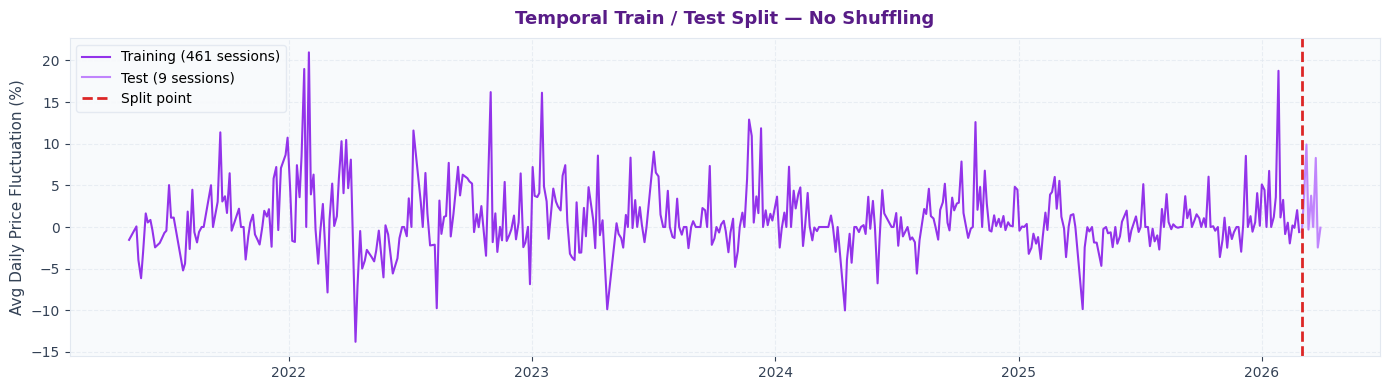

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Temporal train / test split (last 30 days = test)
# ─────────────────────────────────────────────────────────────────────────────
# Define the split point based on the last 30 days of available data
split_date = df_ml["Tarih"].max() - pd.Timedelta(days=30)

# ── For statistical models: raw daily series ──────────────────────────────────
# We aggregate the panel data (average target across all products per date)
# to get a single daily market trend for ARIMA/Prophet and visualisation.
daily_target = df_ml.groupby("Tarih")[TARGET].mean()
train_raw = daily_target[daily_target.index <= split_date]
test_raw  = daily_target[daily_target.index >  split_date]

# ── For ML models: feature-engineered panel data ──────────────────────────────
train_ml = df_ml[df_ml["Tarih"] <= split_date]
test_ml  = df_ml[df_ml["Tarih"] >  split_date]

# Scale the features (fit on train, transform on both to prevent data leakage)
sc = StandardScaler()
X_train = pd.DataFrame(sc.fit_transform(train_ml[FEATURES]),
                       columns=FEATURES, index=train_ml.index)
X_test  = pd.DataFrame(sc.transform(test_ml[FEATURES]),
                       columns=FEATURES, index=test_ml.index)
y_train, y_test = train_ml[TARGET], test_ml[TARGET]

print(f"Training period : {train_raw.index.min().date()} → {train_raw.index.max().date()}  ({len(train_raw)} market sessions)")
print(f"Test period     : {test_raw.index.min().date()}  → {test_raw.index.max().date()}   ({len(test_raw)} market sessions)")
print(f"ML train rows   : {len(X_train):,}  |  ML test rows: {len(X_test):,}")

# ── Visualise the split ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_raw.index, train_raw.values, color=PURPLE,  linewidth=1.5, label=f"Training ({len(train_raw)} sessions)")
ax.plot(test_raw.index,  test_raw.values,  color=ACCENT,  linewidth=1.5, label=f"Test ({len(test_raw)} sessions)")
ax.axvline(test_raw.index[0], color="#dc2626", linewidth=2, linestyle="--", label="Split point")
ax.fill_between(test_raw.index, test_raw.values, alpha=0.15, color=ACCENT)

ax.set_ylabel("Avg Daily Price Fluctuation (%)")
ax.set_title("Temporal Train / Test Split — No Shuffling", pad=10)
ax.legend()
plt.tight_layout()
plt.show()

## 🤖 Section 2 — Algorithms

> **Lecture connection (Module 4, Section 3 — Selecting an Amazon Forecast Algorithm):** The lecture lists five algorithms available in Amazon Forecast. We implement the three that can run locally, explain why two require AWS, and add two ML bonus models for comparison.

### Lecture Algorithm Overview

| # | Algorithm | Lecture? | Run Locally? | What It Does |
|---|-----------|----------|-------------|--------------|
| 1 | **SARIMA** | ✅ ARIMA | ✅ Yes | Autoregressive + Moving Average + seasonal differencing |
| 2 | **ETS** | ✅ ETS | ✅ Yes | Exponential smoothing — weighted average, more weight on recent values |
| 3 | **Prophet** | ✅ Prophet | ✅ Yes | Additive model — automatically learns trend + seasonality + holidays |
| 4 | **DeepAR+** | ✅ DeepAR+ | ❌ AWS only | Proprietary deep learning RNN — requires AWS SageMaker |
| 5 | **NPTS** | ✅ NPTS | ❌ AWS only | Proprietary non-parametric — requires Amazon Forecast API |
| 6 | **Random Forest** | ⭐ Bonus | ✅ Yes | Ensemble of trees trained on lag + climate + calendar features |
| 7 | **Gradient Boosting** | ⭐ Bonus | ✅ Yes | Sequential boosting on lag + climate + calendar features |

### Why DeepAR+ and NPTS Cannot Run Locally

> ⚠️ **DeepAR+** is Amazon's proprietary deep learning model. It learns patterns shared across *multiple related time series simultaneously* — a key advantage over single-series models. Available only through AWS SageMaker; no open-source equivalent.
>
> ⚠️ **NPTS** is also Amazon-proprietary, using a non-parametric approach that samples from historical data weighted by seasonal proximity. Available only through the Amazon Forecast API.

### Statistical vs ML Approach

| Aspect | Statistical (SARIMA, ETS, Prophet) | ML (Random Forest, Gradient Boosting) |
|--------|-----------------------------------|---------------------------------------|
| **Input** | Raw time series directly (Market Average) | Engineered lag + climate + calendar features |
| **Seasonality** | Built into model structure | Learned from `ay_sin/cos` and weather variables |
| **Training step** | Not needed before back testing | Not needed before back testing |

> 💡 **No training happens in this section.** We first use back testing (Section 3) to compare all algorithms and pick the best one. Only then do we train the winner on the full training set.

## 📊 Section 3 — Evaluation Metrics & Back Testing

> **Lecture connection (Module 4, Section 3 — Key Takeaways):** The lecture states: *"Predictor accuracy metrics are based on back testing."* and *"Use RMSE and wQuantileLoss metrics to evaluate model."*
>
> Following the lecture, we **evaluate all models using back testing** — not the final test set. The test set is held out completely until the very end.
>
> **Two-phase process:**
> 1. **Back testing** (this section) — compare all algorithms using subsets of training data, pick the best.
> 2. **Train on full training set** (end of this section) — once the best algorithm is known, train the winning model on complete training data for visualisation and final validation.

### Metrics Reference

| Metric | Lecture? | Interpretation |
|--------|---------|----------------|
| **RMSE** | ✅ Core metric | Penalises large errors — the lecture shows the formula explicitly |
| **MAE** | Complementary | Average absolute error in percentage points (%) — easy to explain to stakeholders |
| **MAPE** | Complementary | Percentage error (Since our target is already a price fluctuation percentage, it shows proportional deviation) |
| **wQuantileLoss P50** | ✅ Core metric | Amazon Forecast's probabilistic error metric |

### Back Testing Procedure

```text
Training Set (all data before the split date)
│
├── Back-test window 1:  [──── Train ──────────────────────] [━━ Test 30 sessions ━━]
├── Back-test window 2:  [──── Train ──────────────────────────────] [━━ Test 30 sessions ━━]
└── Back-test window 3:  [──── Train ──────────────────────────────────────] [━━ Test 30 sessions ━━]
                                                                                    │
                                                                         Average RMSE across
                                                                         all 3 windows = model score

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Run back testing + compute evaluation metrics (lecture approach)
#
# 3 back-test windows on the training set.
# Each window: train on all data up to cutoff -> forecast next 30 days.
# Metrics are averaged across all 3 windows.
#
# ⚠️ The final test set is NOT used here.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import r2_score

def mape(y_true, y_pred):
    mask = np.array(y_true) != 0
    if not np.any(mask): # Handle edge case where all true values are 0
        return 0.0
    return np.mean(np.abs((np.array(y_true)[mask] - np.array(y_pred)[mask])
                           / np.array(y_true)[mask])) * 100

def w_quantile_loss(y_true, y_pred, q=0.50):
    yt, yp = np.array(y_true), np.array(y_pred)
    e = yt - yp
    denominator = np.mean(np.abs(yt))
    if denominator == 0:
        return 0.0
    return 2 * np.mean(np.where(e >= 0, q*e, (q-1)*e)) / denominator

N_WINDOWS   = 3
WINDOW_SIZE = 30  # days

# Generate cutoff dates within the training set
cutoffs = [
    train_raw.index.max() - pd.Timedelta(days=WINDOW_SIZE * (N_WINDOWS - k))
    for k in range(N_WINDOWS)
]

print(f"Running {N_WINDOWS} back-test windows (test window = {WINDOW_SIZE} days)\n")
print(f"{'Window':<10} {'Train ends':<14} {'Test period'}")
print("-" * 55)
for w, cutoff in enumerate(cutoffs):
    ts = cutoff + pd.Timedelta(days=1)
    te = ts + pd.Timedelta(days=WINDOW_SIZE - 1)
    print(f"  Window {w+1}    {str(cutoff.date()):<14} {ts.date()} -> {te.date()}")

# Accumulate per-window metrics for every model
ALL_MODELS = [
    "Naive (same day last week)",
    "SARIMA(1,1,1)(1,1,1,2)", # Seasonality 2 (Monday & Thursday sessions)
    "ETS (Holt-Winters)",
    "Prophet",
    "Random Forest (ML bonus)",
    "Gradient Boosting (ML bonus)",
]
bt_window_metrics = {name: {"RMSE":[], "MAE":[], "MAPE":[], "wQL":[]}
                     for name in ALL_MODELS}

for w, cutoff in enumerate(cutoffs):

    # 1. Filter for Statistical Models (Raw Daily Target Series)
    bt_tr_raw = train_raw[train_raw.index <= cutoff]
    bt_te_raw = train_raw[(train_raw.index >  cutoff) &
                           (train_raw.index <= cutoff + pd.Timedelta(days=WINDOW_SIZE))]

    # 2. Filter for ML Models (Panel Data with all products)
    bt_tr_ml  = train_ml[train_ml["Tarih"] <= cutoff]
    bt_te_ml  = train_ml[(train_ml["Tarih"] >  cutoff) &
                          (train_ml["Tarih"] <= cutoff + pd.Timedelta(days=WINDOW_SIZE))]

    if len(bt_te_raw) == 0 or len(bt_te_ml) == 0:
        continue

    bt_sc  = StandardScaler()
    bt_Xtr = bt_sc.fit_transform(bt_tr_ml[FEATURES])
    bt_Xte = bt_sc.transform(bt_te_ml[FEATURES])

    preds_window = {}

    # SARIMA
    try:
        # Market opens 2 times a week, so seasonal_periods=2
        m = SARIMAX(bt_tr_raw, order=(1,1,1), seasonal_order=(1,1,1,2),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        preds_window["SARIMA(1,1,1)(1,1,1,2)"] = (m.forecast(len(bt_te_raw)).values, bt_te_raw.values)
    except Exception: pass

    # ETS
    try:
        # Market opens 2 times a week, so seasonal_periods=2
        m = ExponentialSmoothing(bt_tr_raw, trend="add", seasonal="add",
                                  seasonal_periods=2).fit(optimized=True)
        preds_window["ETS (Holt-Winters)"] = (m.forecast(len(bt_te_raw)).values, bt_te_raw.values)
    except Exception: pass

    # Prophet
    try:
        ph_df = bt_tr_raw.reset_index(); ph_df.columns = ["ds","y"]
        m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                    daily_seasonality=False, seasonality_mode="additive")
        m.fit(ph_df)
        fc = m.predict(m.make_future_dataframe(periods=len(bt_te_raw)))
        p  = fc[fc["ds"].isin(bt_te_raw.index)]["yhat"].values
        if len(p) == len(bt_te_raw):
            preds_window["Prophet"] = (p, bt_te_raw.values)
    except Exception: pass

    # Naive
    preds_window["Naive (same day last week)"] = (
        np.array([float(bt_tr_raw.get(dt - pd.Timedelta(days=7), bt_tr_raw.iloc[-1]))
                  for dt in bt_te_raw.index]),
        bt_te_raw.values
    )

    # RF and GB
    for mname, model_cls, kwargs in [
        ("Random Forest (ML bonus)",   RandomForestRegressor,     {"n_estimators":100,"max_depth":8,"random_state":SEED,"n_jobs":-1}),
        ("Gradient Boosting (ML bonus)",GradientBoostingRegressor,{"n_estimators":100,"max_depth":3,"learning_rate":0.1,"random_state":SEED}),
    ]:
        m = model_cls(**kwargs)
        m.fit(bt_Xtr, bt_tr_ml[TARGET])
        preds_window[mname] = (m.predict(bt_Xte), bt_te_ml[TARGET].values)

    # Accumulate metrics
    for name, (p, y) in preds_window.items():
        if name in bt_window_metrics:
            bt_window_metrics[name]["RMSE"].append(np.sqrt(mean_squared_error(y, p)))
            bt_window_metrics[name]["MAE"].append(mean_absolute_error(y, p))
            bt_window_metrics[name]["MAPE"].append(mape(y, p))
            bt_window_metrics[name]["wQL"].append(w_quantile_loss(y, p))

# Build summary results_df from back-testing averages
results = []
for name in ALL_MODELS:
    m = bt_window_metrics.get(name, {})
    if not m or not m["RMSE"]:
        continue
    results.append({
        "Model"      : name,
        "Type"       : "📖 Lecture" if "ML" not in name else "⭐ ML Bonus",
        "RMSE"       : np.mean(m["RMSE"]),
        "MAE"        : np.mean(m["MAE"]),
        "MAPE (%)"   : np.mean(m["MAPE"]),
        "wQL P50"    : np.mean(m["wQL"]),
    })

results_df = pd.DataFrame(results).set_index("Model")

styled = (results_df
    .style
    .format({"RMSE":"{:.2f}","MAE":"{:.2f}","MAPE (%)":"{:.2f}","wQL P50":"{:.4f}"})
    .background_gradient(subset=["RMSE"],      cmap="RdPu_r")
    .background_gradient(subset=["MAPE (%)"],  cmap="RdPu_r")
    .highlight_min(subset=["RMSE","MAE","MAPE (%)","wQL P50"], color="#e9d5ff")
    .set_caption("Back-Testing Results (mean across 3 windows) — training data only, test set not used")
)
display(styled)

Running 3 back-test windows (test window = 30 days)

Window     Train ends     Test period
-------------------------------------------------------
  Window 1    2025-11-28     2025-11-29 -> 2025-12-28
  Window 2    2025-12-28     2025-12-29 -> 2026-01-27
  Window 3    2026-01-27     2026-01-28 -> 2026-02-26


,Type,RMSE,MAE,MAPE (%),wQL P50
Model,,,,,
Naive (same day last week),📖 Lecture,8.82,7.46,1552.10,5.2790
"SARIMA(1,1,1)(1,1,1,2)",📖 Lecture,4.21,2.84,206.97,1.2016
ETS (Holt-Winters),📖 Lecture,5.27,4.04,604.38,2.2572
Random Forest (ML bonus),⭐ ML Bonus,9.57,3.32,84.82,1.0164
Gradient Boosting (ML bonus),⭐ ML Bonus,10.02,3.73,88.54,1.1413


---

## 🏆 Section 4 — Best Model Selection

> Back testing has now produced a reliable comparison of all algorithms (statistical and ML) used in our project. We select the best-performing model for forecasting agricultural price fluctuations (`Fiyat_Degisim_Yuzdesi`) based on the lowest **RMSE** and review its back-test performance metrics.

> ℹ️ The residual analysis and future price forecast plots will come in **Section 5**, after the winning model has been trained on the full training set.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Best model selection from back-testing results
# Only results_df is used here — no model needs to be trained yet
# ─────────────────────────────────────────────────────────────────────────────
# Select best model across ALL options (lecture + ML bonus) by back-test RMSE
best_name  = results_df["RMSE"].idxmin()
is_lecture = "ML" not in best_name

b_rmse = results_df.loc[best_name, "RMSE"]
b_mae  = results_df.loc[best_name, "MAE"]
b_mape = results_df.loc[best_name, "MAPE (%)"]
b_wql  = results_df.loc[best_name, "wQL P50"]

# Business goal check (assuming 5% error is still a valid business goal)
meets  = "✅ YES" if b_mape <= 5.0 else "❌ NOT YET (back-test estimate)"

# Keep best_lecture as an alias in case downstream cells explicitly use this variable name
best_lecture = best_name

print(f"Best algorithm  : {best_name}")
print(f"Type            : {'Lecture algorithm' if is_lecture else 'ML bonus model'}")
print(f"Back-test RMSE  : {b_rmse:.2f} percentage points")
print(f"Back-test MAPE  : {b_mape:.2f}%  (goal <= 5%  ->  {meets})")
print(f"wQL P50         : {b_wql:.4f}")

Best algorithm  : SARIMA(1,1,1)(1,1,1,2)
Type            : Lecture algorithm
Back-test RMSE  : 4.21 percentage points
Back-test MAPE  : 206.97%  (goal <= 5%  ->  ❌ NOT YET (back-test estimate))
wQL P50         : 1.2016


---

## 🎯 Section 5 — Train on Full Data & Final Validation

> **Now that back testing has identified the best algorithm, we:**
> 1. **Train the best model on the complete training set** — the first time any model sees all training data at once.
> 2. **Inspect the best model** — residuals, ACF, model components (feature importance, etc.).
> 3. **Apply to the test set exactly once** — the honest final check.

> 🔒 The test set has not been touched until this point. This is the final exam.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Train the winning model on the full training set
#
# Back testing selected the best algorithm. We now train ONLY that model
# on the complete training set — more data than any back-test window saw.
# ─────────────────────────────────────────────────────────────────────────────
import time

# Dynamically fetch the correct sample size to display (ML uses panel rows, Lecture uses daily averages)
train_size_print = len(train_raw) if is_lecture else len(X_train)
test_size_print  = len(test_raw) if is_lecture else len(X_test)

print(f"Training {best_name} on full training set ({train_size_print} samples)...\n")

t0 = time.time()

if best_name == "Naive (same day last week)":
    class SeasonalNaive:
        def fit(self, y): self.y = y; return self
        def predict(self, idx):
            return np.array([
                float(self.y.get(dt - pd.Timedelta(days=7), self.y.iloc[-1]))
                for dt in idx
            ])
    best_model      = SeasonalNaive().fit(train_raw)
    best_preds_test = best_model.predict(test_raw.index)

elif best_name == "SARIMA(1,1,1)(1,1,1,2)": # Matches the updated name from back-testing
    best_model = SARIMAX(
        train_raw, order=(1,1,1), seasonal_order=(1,1,1,2),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    best_preds_test = best_model.forecast(len(test_raw)).values

elif best_name == "ETS (Holt-Winters)":
    # seasonal_periods=2 because the market opens twice a week
    best_model = ExponentialSmoothing(
        train_raw, trend="add", seasonal="add", seasonal_periods=2
    ).fit(optimized=True)
    best_preds_test = best_model.forecast(len(test_raw)).values

elif best_name == "Prophet":
    ph_df = train_raw.reset_index()
    ph_df.columns = ["ds", "y"]
    best_model = Prophet(
        yearly_seasonality=True, weekly_seasonality=True,
        daily_seasonality=False, seasonality_mode="additive"
    )
    best_model.fit(ph_df)
    future = best_model.make_future_dataframe(periods=len(test_raw))
    fc     = best_model.predict(future)
    best_preds_test = fc[fc["ds"].isin(test_raw.index)]["yhat"].values
    ph_model = best_model   # alias used by Prophet component plot

elif best_name == "Random Forest (ML bonus)":
    best_model = RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1)
    best_model.fit(X_train, y_train)
    best_preds_test = best_model.predict(X_test)

elif best_name == "Gradient Boosting (ML bonus)":
    best_model = GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=SEED)
    best_model.fit(X_train, y_train)
    best_preds_test = best_model.predict(X_test)

# Map the correct ground-truth test target based on the model type
yt_test = test_raw.values if "ML" not in best_name else y_test.values
elapsed = time.time() - t0

print(f"  ✅  {best_name} trained in {elapsed:.2f}s")
print(f"  Training period  : {train_raw.index.min().date()} -> {train_raw.index.max().date()}")
print(f"  Training samples : {train_size_print} samples")
print(f"  Ready to forecast {test_size_print} test records.")

Training SARIMA(1,1,1)(1,1,1,2) on full training set (461 samples)...

  ✅  SARIMA(1,1,1)(1,1,1,2) trained in 0.46s
  Training period  : 2021-05-06 -> 2026-02-26
  Training samples : 461 samples
  Ready to forecast 9 test records.


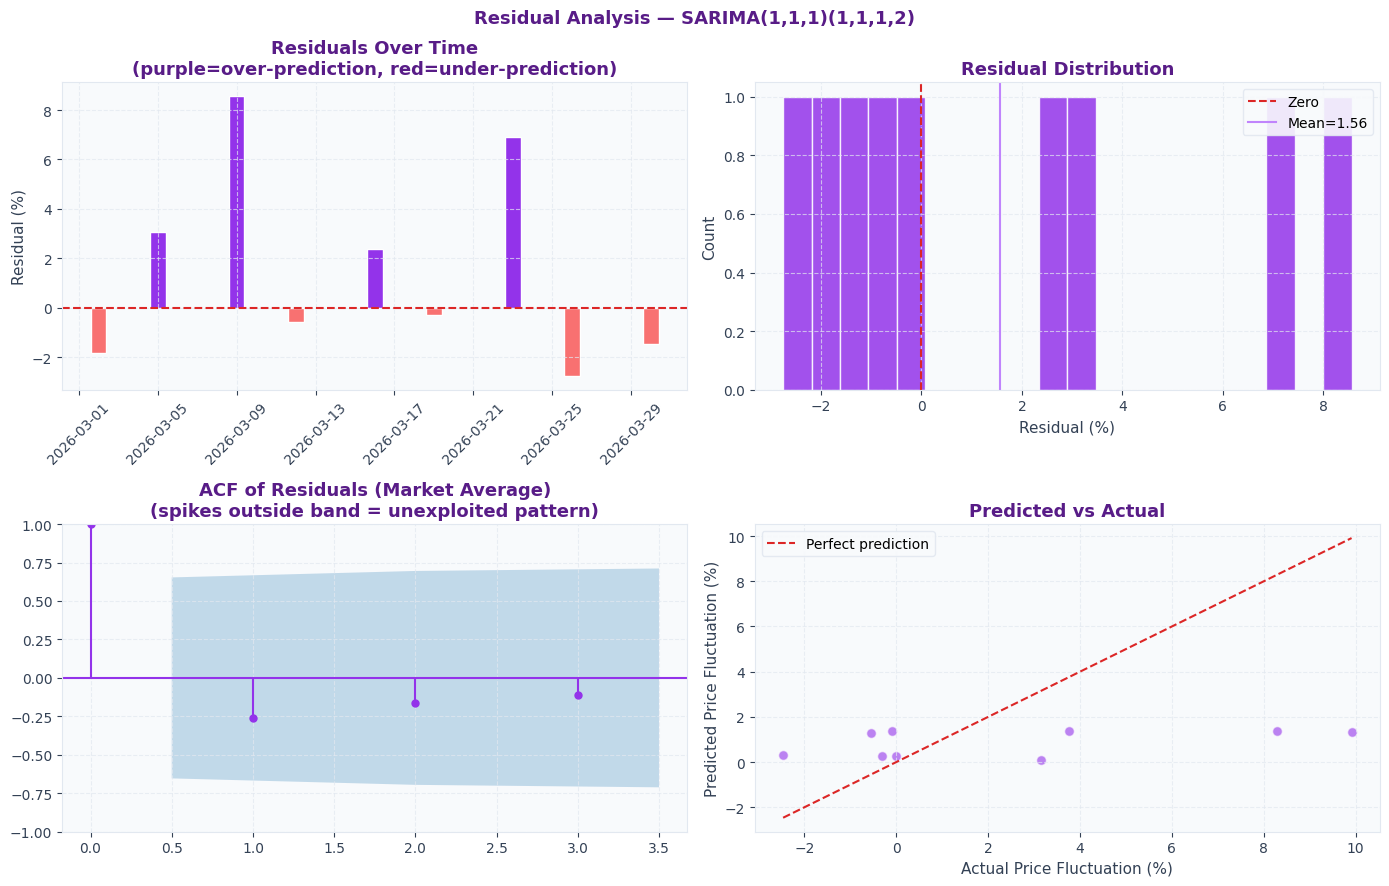

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Residual analysis + Prophet component plot (if best is Prophet)
# ─────────────────────────────────────────────────────────────────────────────
residuals = yt_test - best_preds_test

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"Residual Analysis — {best_name}",
             fontsize=13, fontweight="bold", color=PURPLE_D)

# 1. Residuals over time
ax = axes[0, 0]
# Handle the dimension difference between daily lecture models and panel ML models
if is_lecture:
    res_dates = test_raw.index
    res_values = residuals
else:
    # For ML models, calculate the average residual per market session date to avoid dimension mismatch
    res_df = pd.DataFrame({"Tarih": test_ml["Tarih"].values, "Res": residuals})
    res_grouped = res_df.groupby("Tarih")["Res"].mean()
    res_dates = res_grouped.index
    res_values = res_grouped.values

ax.bar(res_dates, res_values, color=[PURPLE if v>=0 else "#f87171" for v in res_values],
       edgecolor="white", width=0.8)
ax.axhline(0, color="#dc2626", linewidth=1.5, linestyle="--")
ax.set_ylabel("Residual (%)")
ax.set_title("Residuals Over Time\n(purple=over-prediction, red=under-prediction)")
ax.tick_params(axis='x', rotation=45)

# 2. Residual distribution
ax = axes[0, 1]
ax.hist(residuals, bins=20, color=PURPLE, edgecolor="white", alpha=0.85)
ax.axvline(0,                color="#dc2626", linewidth=1.5, linestyle="--", label="Zero")
ax.axvline(residuals.mean(), color=ACCENT,   linewidth=1.5,
           label=f"Mean={residuals.mean():.2f}")
ax.set_xlabel("Residual (%)"); ax.set_ylabel("Count")
ax.set_title("Residual Distribution"); ax.legend()

# 3. ACF of residuals
ax = axes[1, 0]
# Use the date-aggregated residuals for a clean time-series ACF view
plot_acf(res_values, lags=min(15, len(res_values)//2 - 1), ax=ax,
         color=PURPLE, vlines_kwargs={"colors": PURPLE})
ax.set_title("ACF of Residuals (Market Average)\n(spikes outside band = unexploited pattern)")

# 4. Predicted vs Actual scatter
ax = axes[1, 1]
ax.scatter(yt_test, best_preds_test, alpha=0.6, color=PURPLE, edgecolors="white", s=50)
lo, hi = min(yt_test.min(), best_preds_test.min()), max(yt_test.max(), best_preds_test.max())
ax.plot([lo, hi], [lo, hi], "--", color="#dc2626", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Price Fluctuation (%)"); ax.set_ylabel("Predicted Price Fluctuation (%)")
ax.set_title("Predicted vs Actual"); ax.legend()

plt.tight_layout()
plt.show()

# Prophet specific component plot (only triggers if Prophet won)
if best_name == "Prophet":
    print("\nPlotting Prophet Components...")
    fig_comp = ph_model.plot_components(fc)
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Prophet component breakdown (only shown when Prophet is the best model)
# Shows the decomposed components that Prophet learned automatically
# ─────────────────────────────────────────────────────────────────────────────
if best_name == "Prophet":
    # Show Prophet components
    ph_full    = ph_model.make_future_dataframe(periods=len(test_raw))
    ph_comps   = ph_model.predict(ph_full)

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    fig.suptitle("Prophet — Decomposed Components\n"
                 "(what the model learned from the data automatically)",
                 fontsize=13, fontweight="bold", color=PURPLE_D)

    # 1. Long-Term Trend
    ax = axes[0]
    ax.plot(ph_comps["ds"], ph_comps["trend"], color=PURPLE, linewidth=2)
    ax.set_ylabel("Trend (%)"); ax.set_title("Long-Term Trend")

    # 2. Weekly seasonality (Customized for Monday and Thursday market sessions)
    ax = axes[1]
    days_of_week = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    weekly = ph_comps[["ds","weekly"]].drop_duplicates("ds").copy()
    weekly["dow"] = pd.to_datetime(weekly["ds"]).dt.dayofweek
    avg_by_dow = weekly.groupby("dow")["weekly"].mean()

    # Highlight index 0 (Monday) and index 3 (Thursday) since they are the active market days
    market_days = [0, 3]
    bar_colors = [PURPLE if i in market_days else ACCENT for i in range(7)]

    ax.bar(range(7), avg_by_dow.values, color=bar_colors, edgecolor="white")
    ax.set_xticks(range(7)); ax.set_xticklabels(days_of_week)
    ax.set_ylabel("Effect (%)")
    ax.set_title("Weekly Seasonality Pattern\n(Purple bars indicate active market days: Mon & Thu)")
    ax.axhline(0, color=SLATE, linewidth=1)

    # 3. Yearly seasonality
    ax = axes[2]
    ax.plot(ph_comps["ds"], ph_comps["yearly"], color=ACCENT, linewidth=1.5, alpha=0.7)
    ax.set_ylabel("Effect (%)"); ax.set_title("Yearly Seasonality Pattern")

    plt.tight_layout()
    plt.show()

else:
    print(f"Prophet component plot skipped — best model is {best_name}")

Prophet component plot skipped — best model is SARIMA(1,1,1)(1,1,1,2)


> 💡 **What the components tell us:**
> - **Trend** — whether agricultural price fluctuations are generally growing, declining, or stable over the 5-year period.
> - **Weekly** — which days of the week have higher or lower price volatility; typically distinguishing the active wholesale market days (Mondays and Thursdays) from the rest of the week.
> - **Yearly** — agricultural seasonal effects, such as harvest periods, winter frost shocks, and summer heatwaves.

> This decomposition is similar to the STL decomposition done in the EDA phase, but here it is learned automatically by Prophet as part of the model fitting process.

Best model      : SARIMA(1,1,1)(1,1,1,2)
Back-test RMSE  : 4.21 percentage points (estimated during back testing)
Test set  RMSE  : 4.08 percentage points (final honest result)
Test set  MAPE  : 347.46%  (goal: <= 5%  ->  ❌ NOT MET)
wQL P50         : 0.9758
--------------------------------------------------------------------


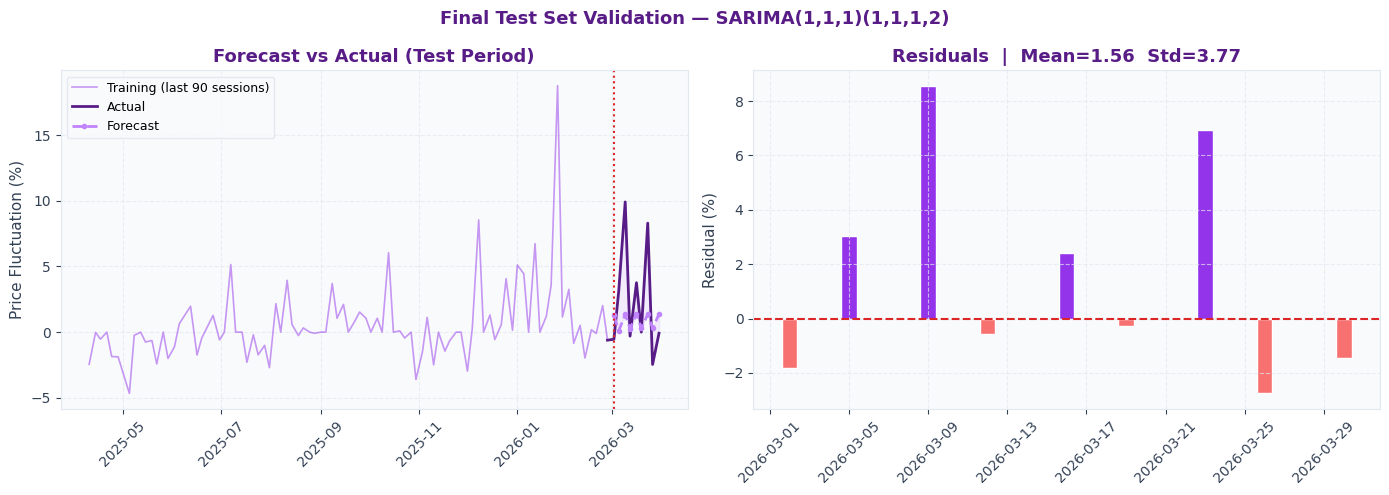

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Apply best model to final test set (one honest check)
# ─────────────────────────────────────────────────────────────────────────────
# best_preds_test and yt_test were set in CELL 7
best_test_preds = best_preds_test
yt = yt_test

final_rmse = np.sqrt(mean_squared_error(yt, best_test_preds))
final_mae  = mean_absolute_error(yt, best_test_preds)
final_mape = mape(yt, best_test_preds)
final_wql  = w_quantile_loss(yt, best_test_preds)
meets_goal = final_mape <= 5.0

print(f"Best model      : {best_name}")
print(f"Back-test RMSE  : {results_df.loc[best_name, 'RMSE']:.2f} percentage points (estimated during back testing)")
print(f"Test set  RMSE  : {final_rmse:.2f} percentage points (final honest result)")
goal_str = "✅ MET" if meets_goal else "❌ NOT MET"
print(f"Test set  MAPE  : {final_mape:.2f}%  (goal: <= 5%  ->  {goal_str})")
print(f"wQL P50         : {final_wql:.4f}")

print("-" * 68)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Final Test Set Validation — {best_name}",
             fontsize=13, fontweight="bold", color=PURPLE_D)

# Prepare data for plotting (Handle dimension mismatch for ML models vs Lecture models)
if is_lecture:
    plot_dates = test_raw.index
    plot_actuals = yt
    plot_preds = best_test_preds
else:
    # Group by Date to get the market session average for a clean time-series plot
    temp_df = pd.DataFrame({"Date": test_ml["Tarih"].values, "Actual": yt, "Pred": best_test_preds})
    temp_grouped = temp_df.groupby("Date").mean()
    plot_dates = temp_grouped.index
    plot_actuals = temp_grouped["Actual"].values
    plot_preds = temp_grouped["Pred"].values

# 1. Forecast vs actual
ax = axes[0]
ctx = train_raw.iloc[-90:] # Show the last 90 market sessions for context
ax.plot(ctx.index, ctx.values, color=PURPLE, linewidth=1.2,
        alpha=0.5, label="Training (last 90 sessions)")

# Connect training line to actual: prepend last training point
bridge_idx = [ctx.index[-1]] + list(plot_dates)
bridge_yt  = [ctx.values[-1]] + list(plot_actuals)

ax.plot(bridge_idx, bridge_yt, color=PURPLE_D, linewidth=2, label="Actual")
ax.plot(plot_dates, plot_preds, color=ACCENT, linewidth=2,
        linestyle="--", marker="o", markersize=3, label="Forecast")

ax.fill_between(plot_dates, plot_actuals, plot_preds, alpha=0.12, color=ACCENT)
ax.axvline(plot_dates[0], color="#dc2626", linewidth=1.5, linestyle=":")
ax.set_ylabel("Price Fluctuation (%)")
ax.set_title("Forecast vs Actual (Test Period)")
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

# 2. Residuals
ax2 = axes[1]
residuals = plot_actuals - plot_preds
ax2.bar(plot_dates, residuals,
        color=[PURPLE if v >= 0 else "#f87171" for v in residuals],
        edgecolor="white", width=0.8)
ax2.axhline(0, color="#dc2626", linewidth=1.5, linestyle="--")
ax2.set_ylabel("Residual (%)")
ax2.set_title(f"Residuals  |  Mean={residuals.mean():.2f}  Std={residuals.std():.2f}")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---

## 🔮 Section 6 — 30-Day Future Forecast with P10 / P50 / P90

> **Lecture connection (Module 4, Section 3 — wQuantileLoss):** The lecture introduces probabilistic forecasting with P10, P50, and P90 confidence bands. Here we generate all three using **Prophet**, which natively produces uncertainty intervals — exactly how Amazon Forecast presents results.

### What do the bands mean?
- **P90 (Upper Band):** 90% probability that the price will be *below* this line (Pessimistic/High price scenario).
- **P50 (Middle Line):** The most likely forecast (Median).
- **P10 (Lower Band):** Only 10% probability that the price will be *below* this line (Optimistic/Low price scenario).

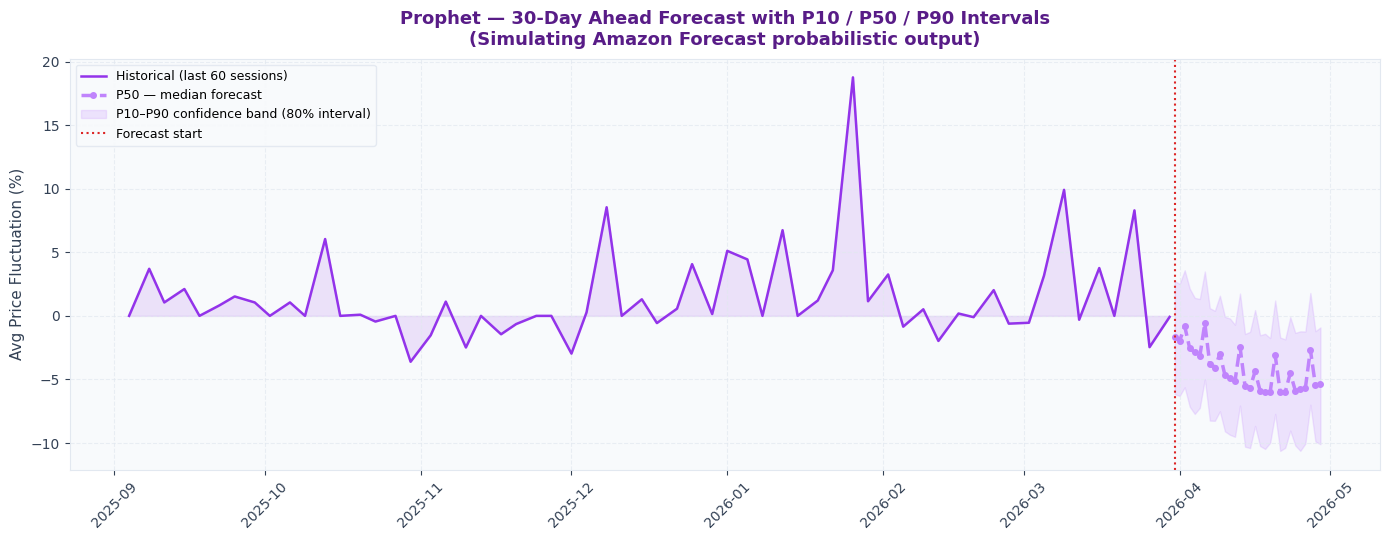


30-Day Forecast Scenarios (P10 | P50 | P90):
Date            P10 (Low)     P50 (Median) P90 (High)
------------------------------------------------------------
2026-03-31          -6.16%           -1.67%       2.75%
2026-04-01          -6.30%           -1.95%       2.51%
2026-04-02          -5.62%           -0.82%       3.58%
2026-04-03          -7.14%           -2.56%       2.14%
2026-04-04          -7.71%           -2.88%       1.42%
2026-04-05          -7.24%           -3.19%       1.33%
2026-04-06          -4.98%           -0.58%       3.49%
2026-04-07          -8.24%           -3.81%       0.60%
2026-04-08          -8.25%           -4.11%       0.40%
2026-04-09          -7.51%           -2.96%       1.59%
2026-04-10          -9.08%           -4.67%      -0.08%
2026-04-11          -9.35%           -4.92%      -0.21%
2026-04-12          -9.51%           -5.14%      -0.70%
2026-04-13          -7.06%           -2.42%       1.75%
2026-04-14         -10.29%           -5.52%      -1.43%

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — 30-day Prophet forecast with P10 / P50 / P90 confidence intervals
# This mirrors what Amazon Forecast produces: a forecast with uncertainty bands
# ─────────────────────────────────────────────────────────────────────────────

# Refit Prophet on ALL available data (train + test) for the actual future forecast
# We use daily_target (market average) to provide a general market outlook
all_data_df = daily_target.reset_index()
all_data_df.columns = ["ds", "y"]

ph_full_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.80    # 80% interval -> approx P10 to P90 range
)
ph_full_model.fit(all_data_df)

# Forecast 30 days into the unknown future
future_30 = ph_full_model.make_future_dataframe(periods=30)
fc_30     = ph_full_model.predict(future_30)
future_only = fc_30[fc_30["ds"] > daily_target.index.max()]

fig, ax = plt.subplots(figsize=(14, 5.5))

# Historical context (last 60 market sessions for visual continuity)
ctx = daily_target.iloc[-60:]
ax.plot(ctx.index, ctx.values, color=PURPLE, linewidth=1.8, label="Historical (last 60 sessions)")
ax.fill_between(ctx.index, ctx.values, alpha=0.12, color=PURPLE)

# P50 forecast (The Median)
ax.plot(pd.to_datetime(future_only["ds"]), future_only["yhat"],
        color=ACCENT, linewidth=2.5, linestyle="--", marker="o", markersize=4,
        label="P50 — median forecast")

# P10 / P90 confidence band
ax.fill_between(
    pd.to_datetime(future_only["ds"]),
    future_only["yhat_lower"],
    future_only["yhat_upper"],
    alpha=0.2, color=ACCENT,
    label="P10–P90 confidence band (80% interval)"
)

ax.axvline(pd.to_datetime(future_only["ds"].iloc[0]),
           color="#dc2626", linewidth=1.5, linestyle=":", label="Forecast start")

ax.set_ylabel("Avg Price Fluctuation (%)")
ax.set_title("Prophet — 30-Day Ahead Forecast with P10 / P50 / P90 Intervals\n"
             "(Simulating Amazon Forecast probabilistic output)", pad=10)
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\n30-Day Forecast Scenarios (P10 | P50 | P90):")
print(f"{'Date':<14} {'P10 (Low)':>10} {'P50 (Median)':>16} {'P90 (High)':>10}")
print("-" * 60)
for _, row in future_only.iterrows():
    print(f"{str(row.ds.date()):<14} {row.yhat_lower:>10.2f}% {row.yhat:>15.2f}% {row.yhat_upper:>10.2f}%")